In [1]:
import csv
import mplhep
import ROOT
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
mplhep.style.use('ROOT')

Welcome to JupyROOT 6.22/08


In [2]:
stats = pd.read_csv('filter-cellstats.csv')

In [6]:
stats.describe()

,Layer,U,V,Constant,Constant_Error,MPV,MPV_Error,Sigma,Sigma_Error,Chi2,P,NDF
count,14688.000000,14688.000000,14688.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000
mean,16.500000,11.666667,11.333333,2301.653555,11357.557167,2.003672e-01,1.072999,0.299449,1.015185,9.372856e+00,0.543328,7.718750
std,9.811042,6.320377,6.320377,16532.392215,88913.849964,6.404155e-01,1.715547,1.552986,5.473914,1.513222e+01,0.301200,5.568148
min,0.000000,0.000000,0.000000,7.266698,1.000000,1.019046e-11,0.001989,0.000447,0.000962,6.386063e-09,0.000000,0.000000
25%,8.000000,7.000000,6.000000,16.472586,9.019236,2.679908e-03,0.005130,0.014962,0.002701,2.367508e+00,0.252305,4.000000
50%,16.500000,12.000000,11.000000,57.013535,21.999540,1.369831e-01,0.023136,0.021679,0.007058,5.315600e+00,0.619616,6.000000
75%,25.000000,17.000000,16.000000,132.322526,41.777916,1.533976e-01,2.652569,0.087119,0.149801,9.119328e+00,0.791198,10.000000
max,33.000000,23.000000,23.000000,160411.249371,865102.714389,4.985738e+00,4.994972,14.609004,49.559130,7.935875e+01,0.980989,29.000000


In [16]:
len(stats.MPV)-np.isnan(stats.MPV).sum()

96

(array([26.,  2.,  0.,  2.,  2., 36., 19.,  2.,  1.,  1.,  2.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.

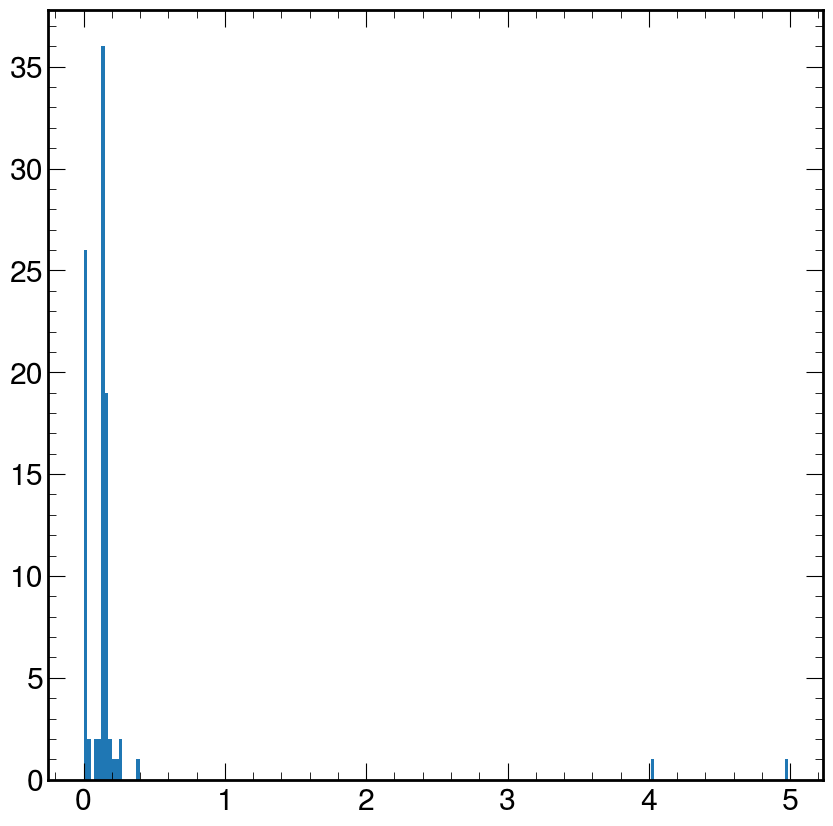

In [11]:
import matplotlib.pyplot as plt
plt.hist(stats.MPV, bins=200)

In [20]:
stats.Layer[~np.isnan(stats.MPV)]

87     True
88     True
90     True
97     True
105    True
       ... 
311    True
312    True
328    True
329    True
331    True
Name: Layer, Length: 96, dtype: bool

In [3]:
l = 0
cell_list = []
for i, row in stats.iterrows():
    l = int(row['Layer'])
    u = int(row['U'])
    v =int(row['V'])
    x = 'MAC2_cell_amplitude_l'+ str(l)+'_m0_u'+str(u)+'_v'+str(v)
    cell_list.append(x)
    

In [5]:
len(cell_list)

14688

In [21]:
stats.describe()

,Layer,U,V,Constant,Constant_Error,MPV,MPV_Error,Sigma,Sigma_Error,Chi2,P,NDF
count,14688.000000,14688.000000,14688.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000
mean,16.500000,11.666667,11.333333,2301.653555,11357.557167,2.003672e-01,1.072999,0.299449,1.015185,9.372856e+00,0.543328,7.718750
std,9.811042,6.320377,6.320377,16532.392215,88913.849964,6.404155e-01,1.715547,1.552986,5.473914,1.513222e+01,0.301200,5.568148
min,0.000000,0.000000,0.000000,7.266698,1.000000,1.019046e-11,0.001989,0.000447,0.000962,6.386063e-09,0.000000,0.000000
25%,8.000000,7.000000,6.000000,16.472586,9.019236,2.679908e-03,0.005130,0.014962,0.002701,2.367508e+00,0.252305,4.000000
50%,16.500000,12.000000,11.000000,57.013535,21.999540,1.369831e-01,0.023136,0.021679,0.007058,5.315600e+00,0.619616,6.000000
75%,25.000000,17.000000,16.000000,132.322526,41.777916,1.533976e-01,2.652569,0.087119,0.149801,9.119328e+00,0.791198,10.000000
max,33.000000,23.000000,23.000000,160411.249371,865102.714389,4.985738e+00,4.994972,14.609004,49.559130,7.935875e+01,0.980989,29.000000


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Abnormal termination of minimization.
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is empty 
Warning in <Fit>: Fit data is e

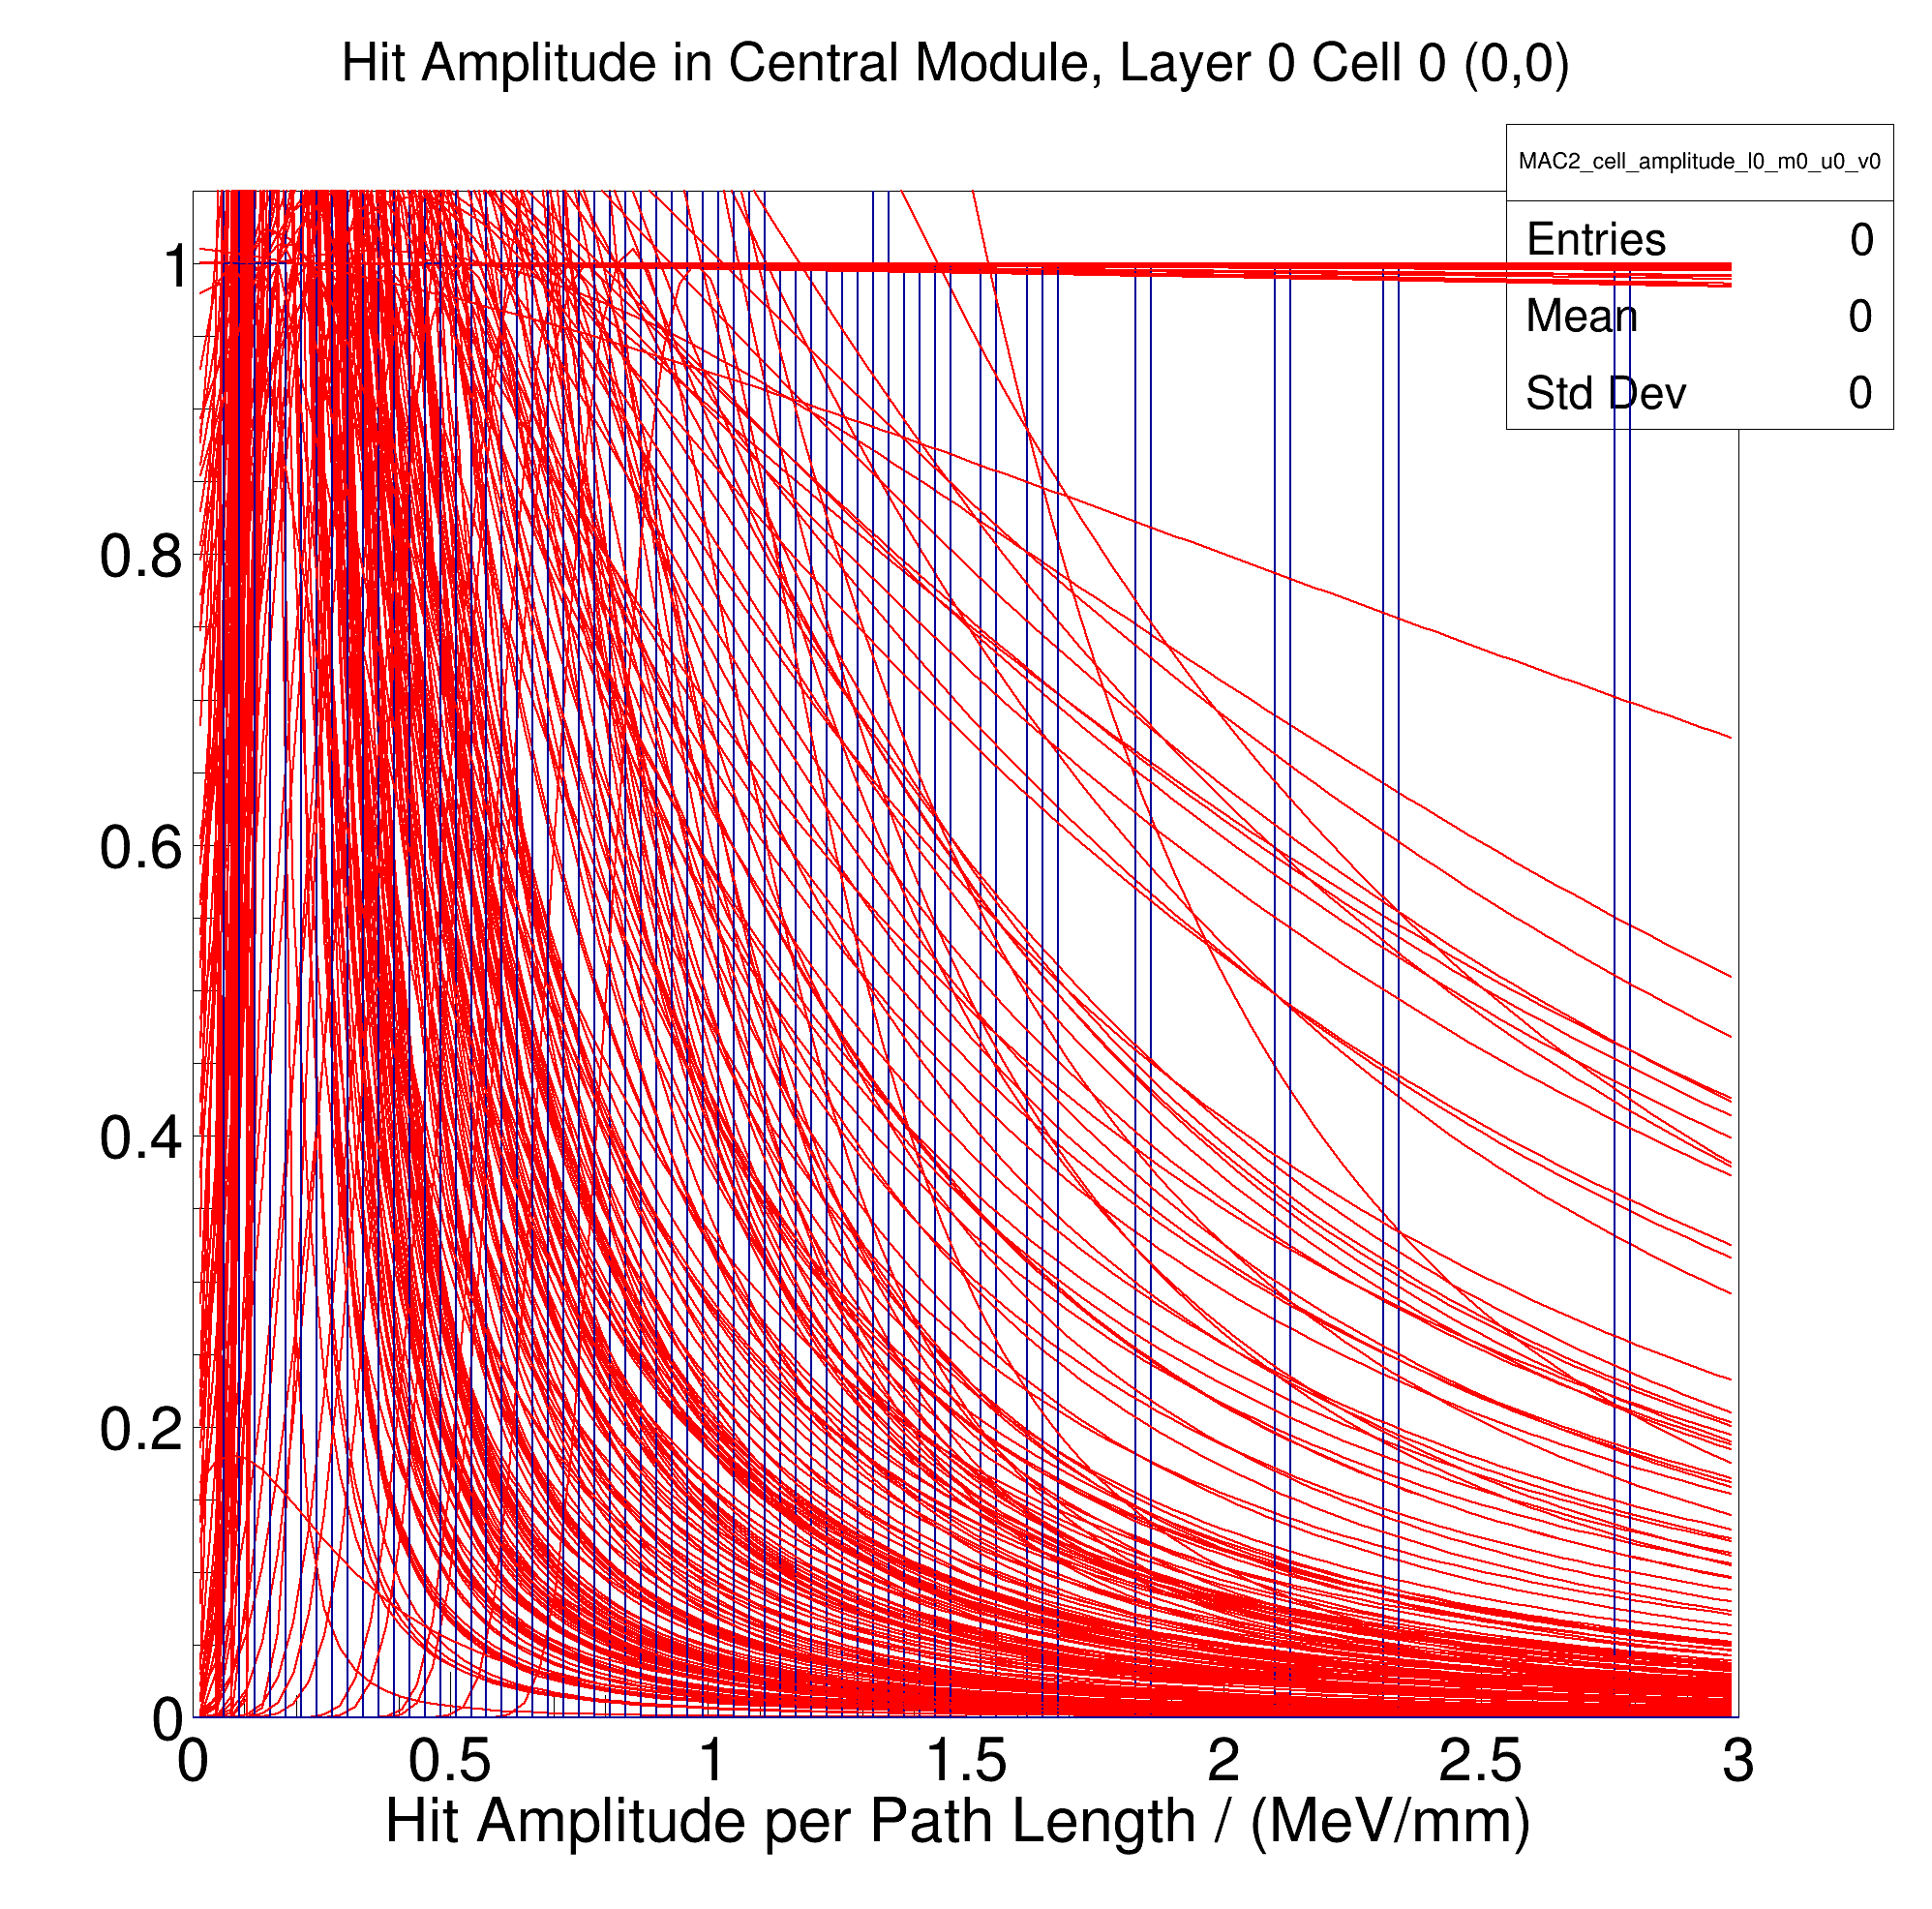

In [4]:
f = ROOT.TFile('hist-filtering.root')
d = f.Get('MAC2')
c = ROOT.TCanvas("c1","c1",2000,2000)

for i_cell in cell_list:
    #print(cell_list)
    h = d.Get(i_cell)
    fl = ROOT.TF1('seedparamslandau','landau')
    fl.SetParameters(1,0.1,0.1)
    fl.SetParLimits(1,0,5)
    fl.SetRange(h.GetXaxis().GetXmin(), h.GetXaxis().GetXmax())
    fr = h.Fit(fl, 'BSM0').Get()
    h.Draw('SAME')    
    fl.Draw('SAME')

c.Draw('SAME')
# #for x in cell_list:
# h = d.Get(a)
# #h.GetXaxis().SetRangeUser(0, 1.5)
# #h.Draw()
# fr = h.Fit(fl,'BSM').Get()
# h.Draw()
# c.Draw()

MAC2_cell_amplitude_l0_m0_u1_v8
MAC2_cell_amplitude_l0_m0_u1_v11
 FCN=2.39202e-08 FROM HESSE     STATUS=NOT POSDEF     16 CALLS          98 TOTAL
                     EDM=4.82486e-08    STRATEGY= 1      ERR MATRIX NOT POS-DEF
  EXT PARAMETER                APPROXIMATE        STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     5.61126e+00   8.20406e+01   1.09438e-04   5.51339e-05
   2  MPV          2.22626e-01   4.24189e+00   3.05908e-05  -1.98143e-04
   3  Sigma        1.90256e-01   4.28077e+01   1.37347e-05   8.84899e-05
 FCN=8.32908e-08 FROM HESSE     STATUS=NOT POSDEF     28 CALLS         121 TOTAL
                     EDM=6.61467e-07    STRATEGY= 1      ERR MATRIX NOT POS-DEF
  EXT PARAMETER                APPROXIMATE        STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     5.53583e+00   7.35024e-01   1.08139e-04  -1.04237e-04
   2  MPV          1.42983e-01   

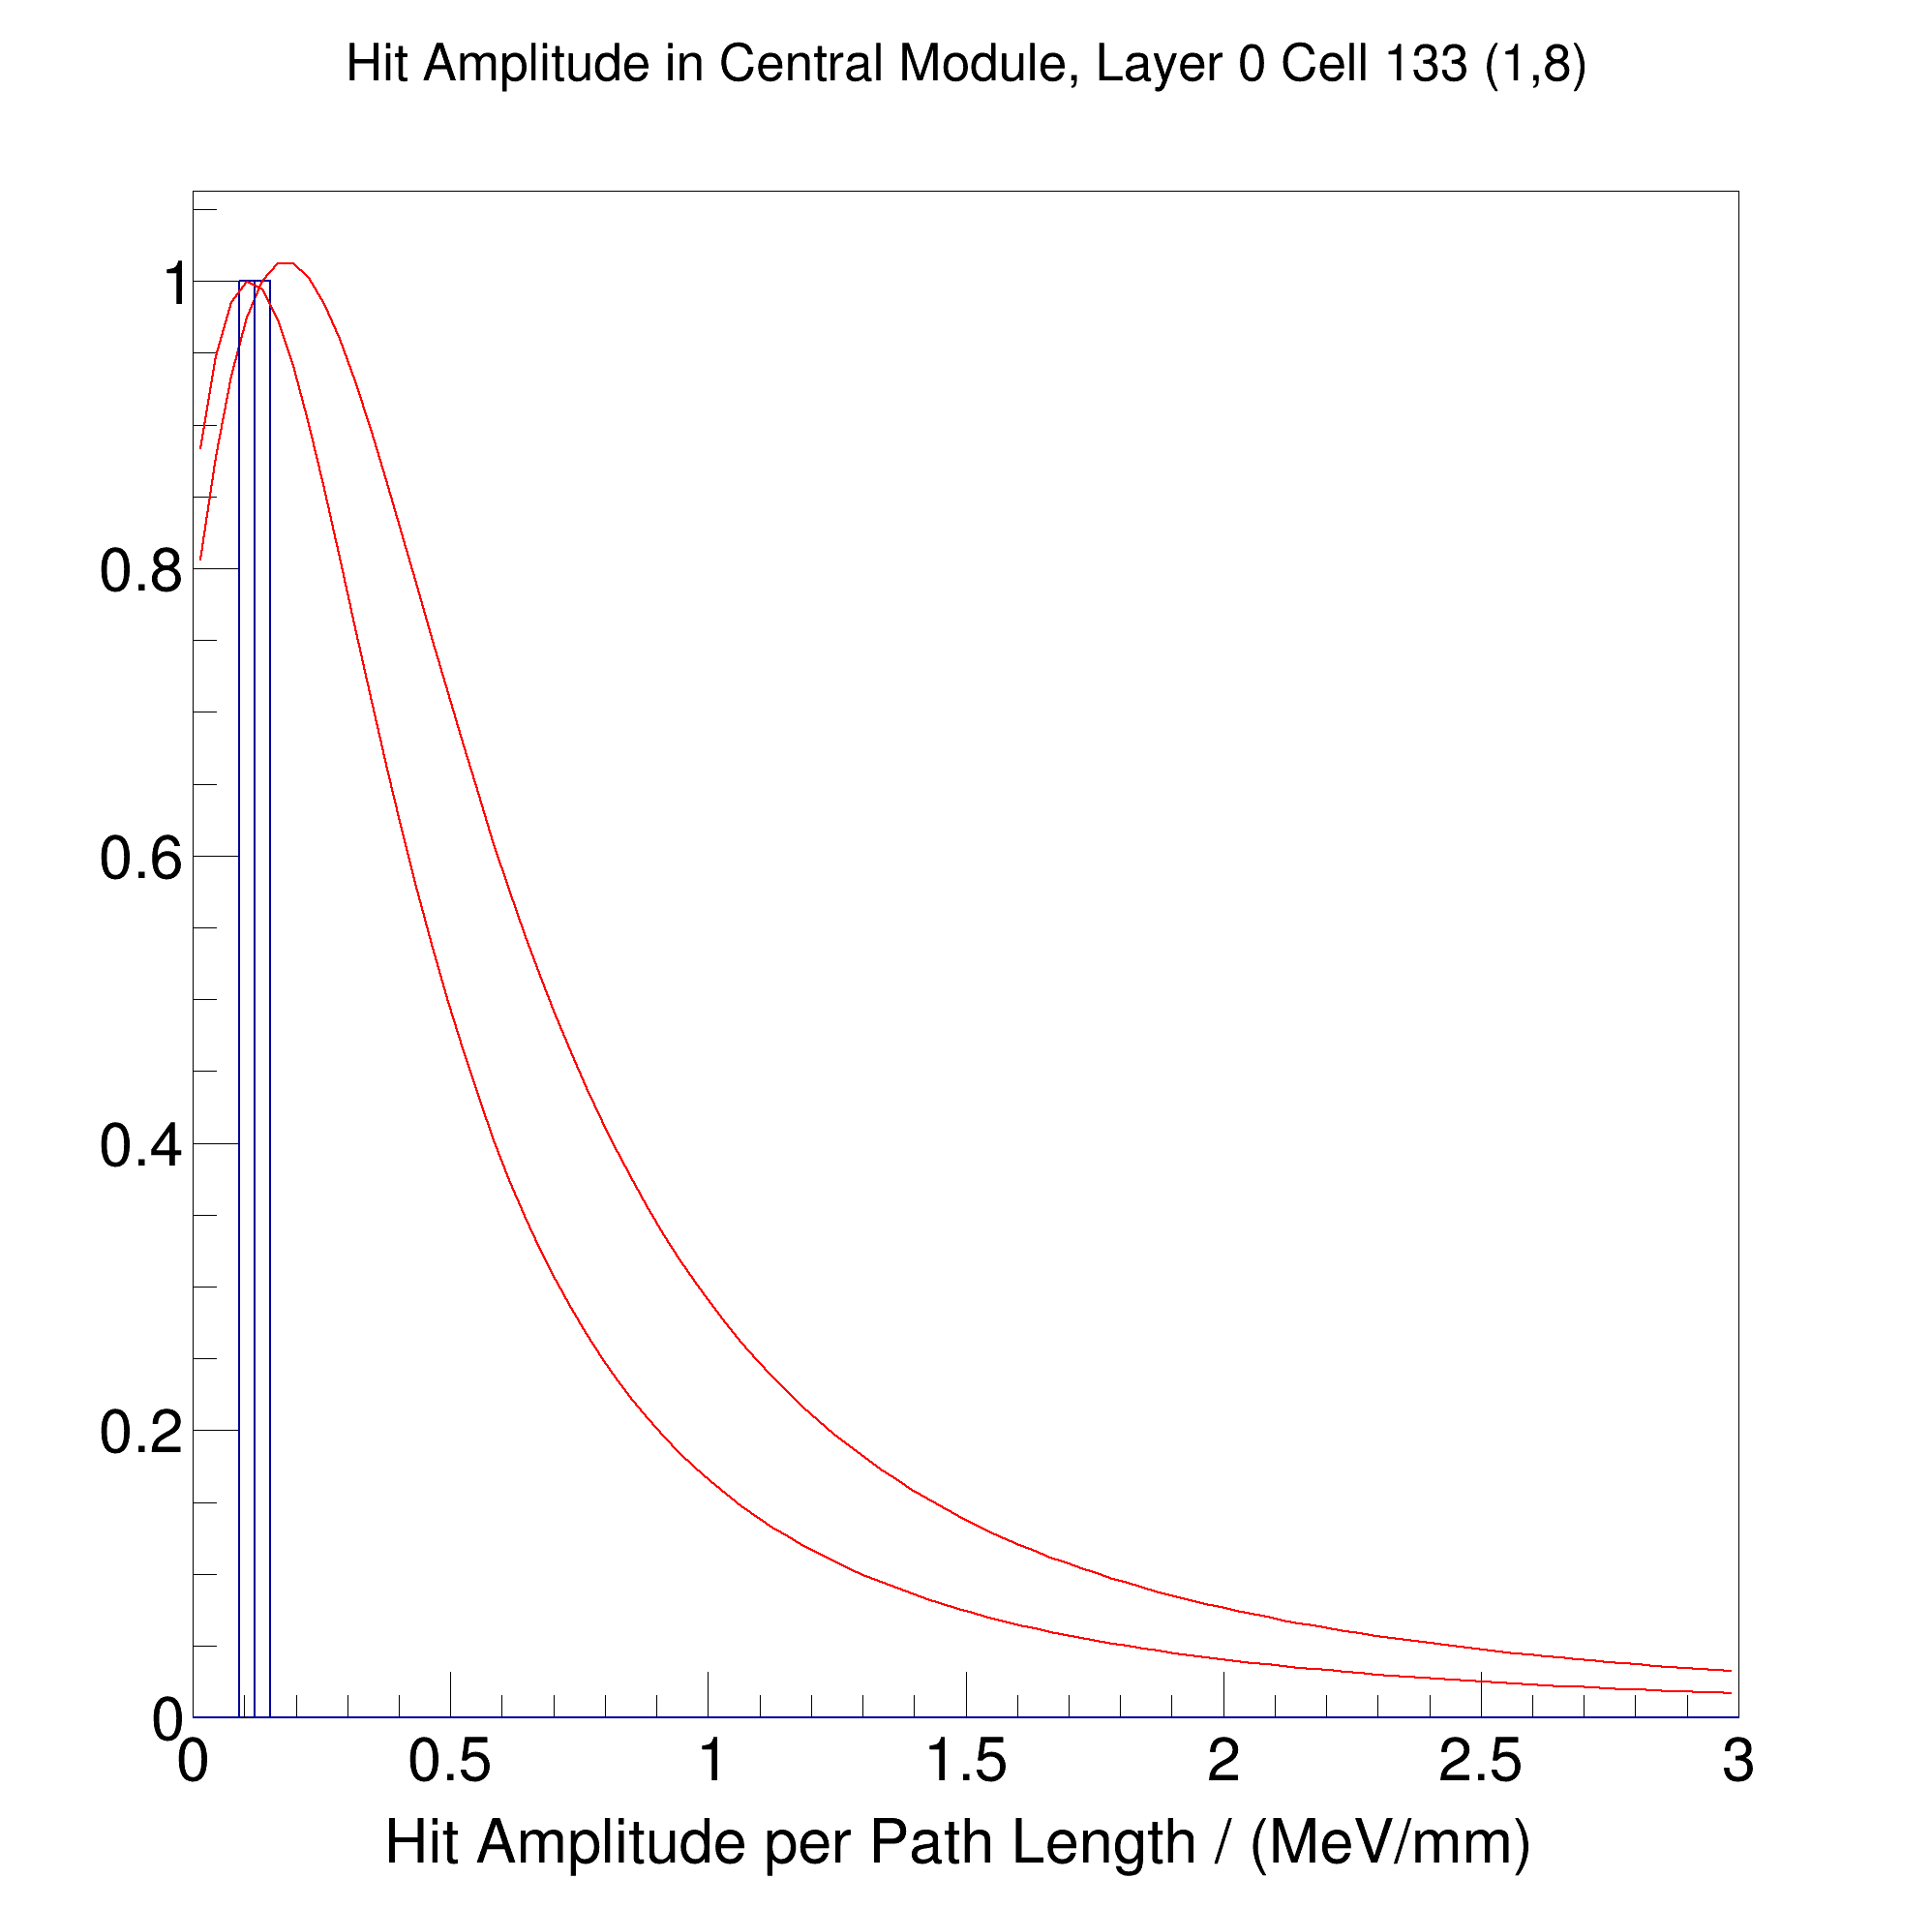

In [10]:
f = ROOT.TFile('hist-filtering.root')
d = f.Get('MAC2')
c = ROOT.TCanvas("c1","c1",2000,2000)

for i_cell in [20,23]:
    print(cell_list[i_cell])
    h = d.Get(cell_list[i_cell])
    fl = ROOT.TF1('seedparamslandau','landau')
    fl.SetParameters(1,0.1,0.1)
    fl.SetParLimits(1,0,5)
    fl.SetRange(h.GetXaxis().GetXmin(), h.GetXaxis().GetXmax())
    fr = h.Fit(fl, 'BSM0').Get()
    h.Draw('SAME')    
    fl.Draw('SAME')

c.Draw('SAME')
# #for x in cell_list:
# h = d.Get(a)
# #h.GetXaxis().SetRangeUser(0, 1.5)
# #h.Draw()
# fr = h.Fit(fl,'BSM').Get()
# h.Draw()
# c.Draw()

In [52]:
b = cell_list[23]


 FCN=3.88834e-14 FROM HESSE     STATUS=NOT POSDEF     26 CALLS         134 TOTAL
                     EDM=2.14526e-13    STRATEGY= 1      ERR MATRIX NOT POS-DEF
  EXT PARAMETER                APPROXIMATE        STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     5.53618e+00   4.54882e-01   1.08129e-04  -7.12364e-08
   2  MPV          1.40776e-01   3.98795e+00   9.47722e-02   3.19025e-08
   3  Sigma        1.44123e-01   9.43262e+01   6.01327e-06  -7.65441e-09


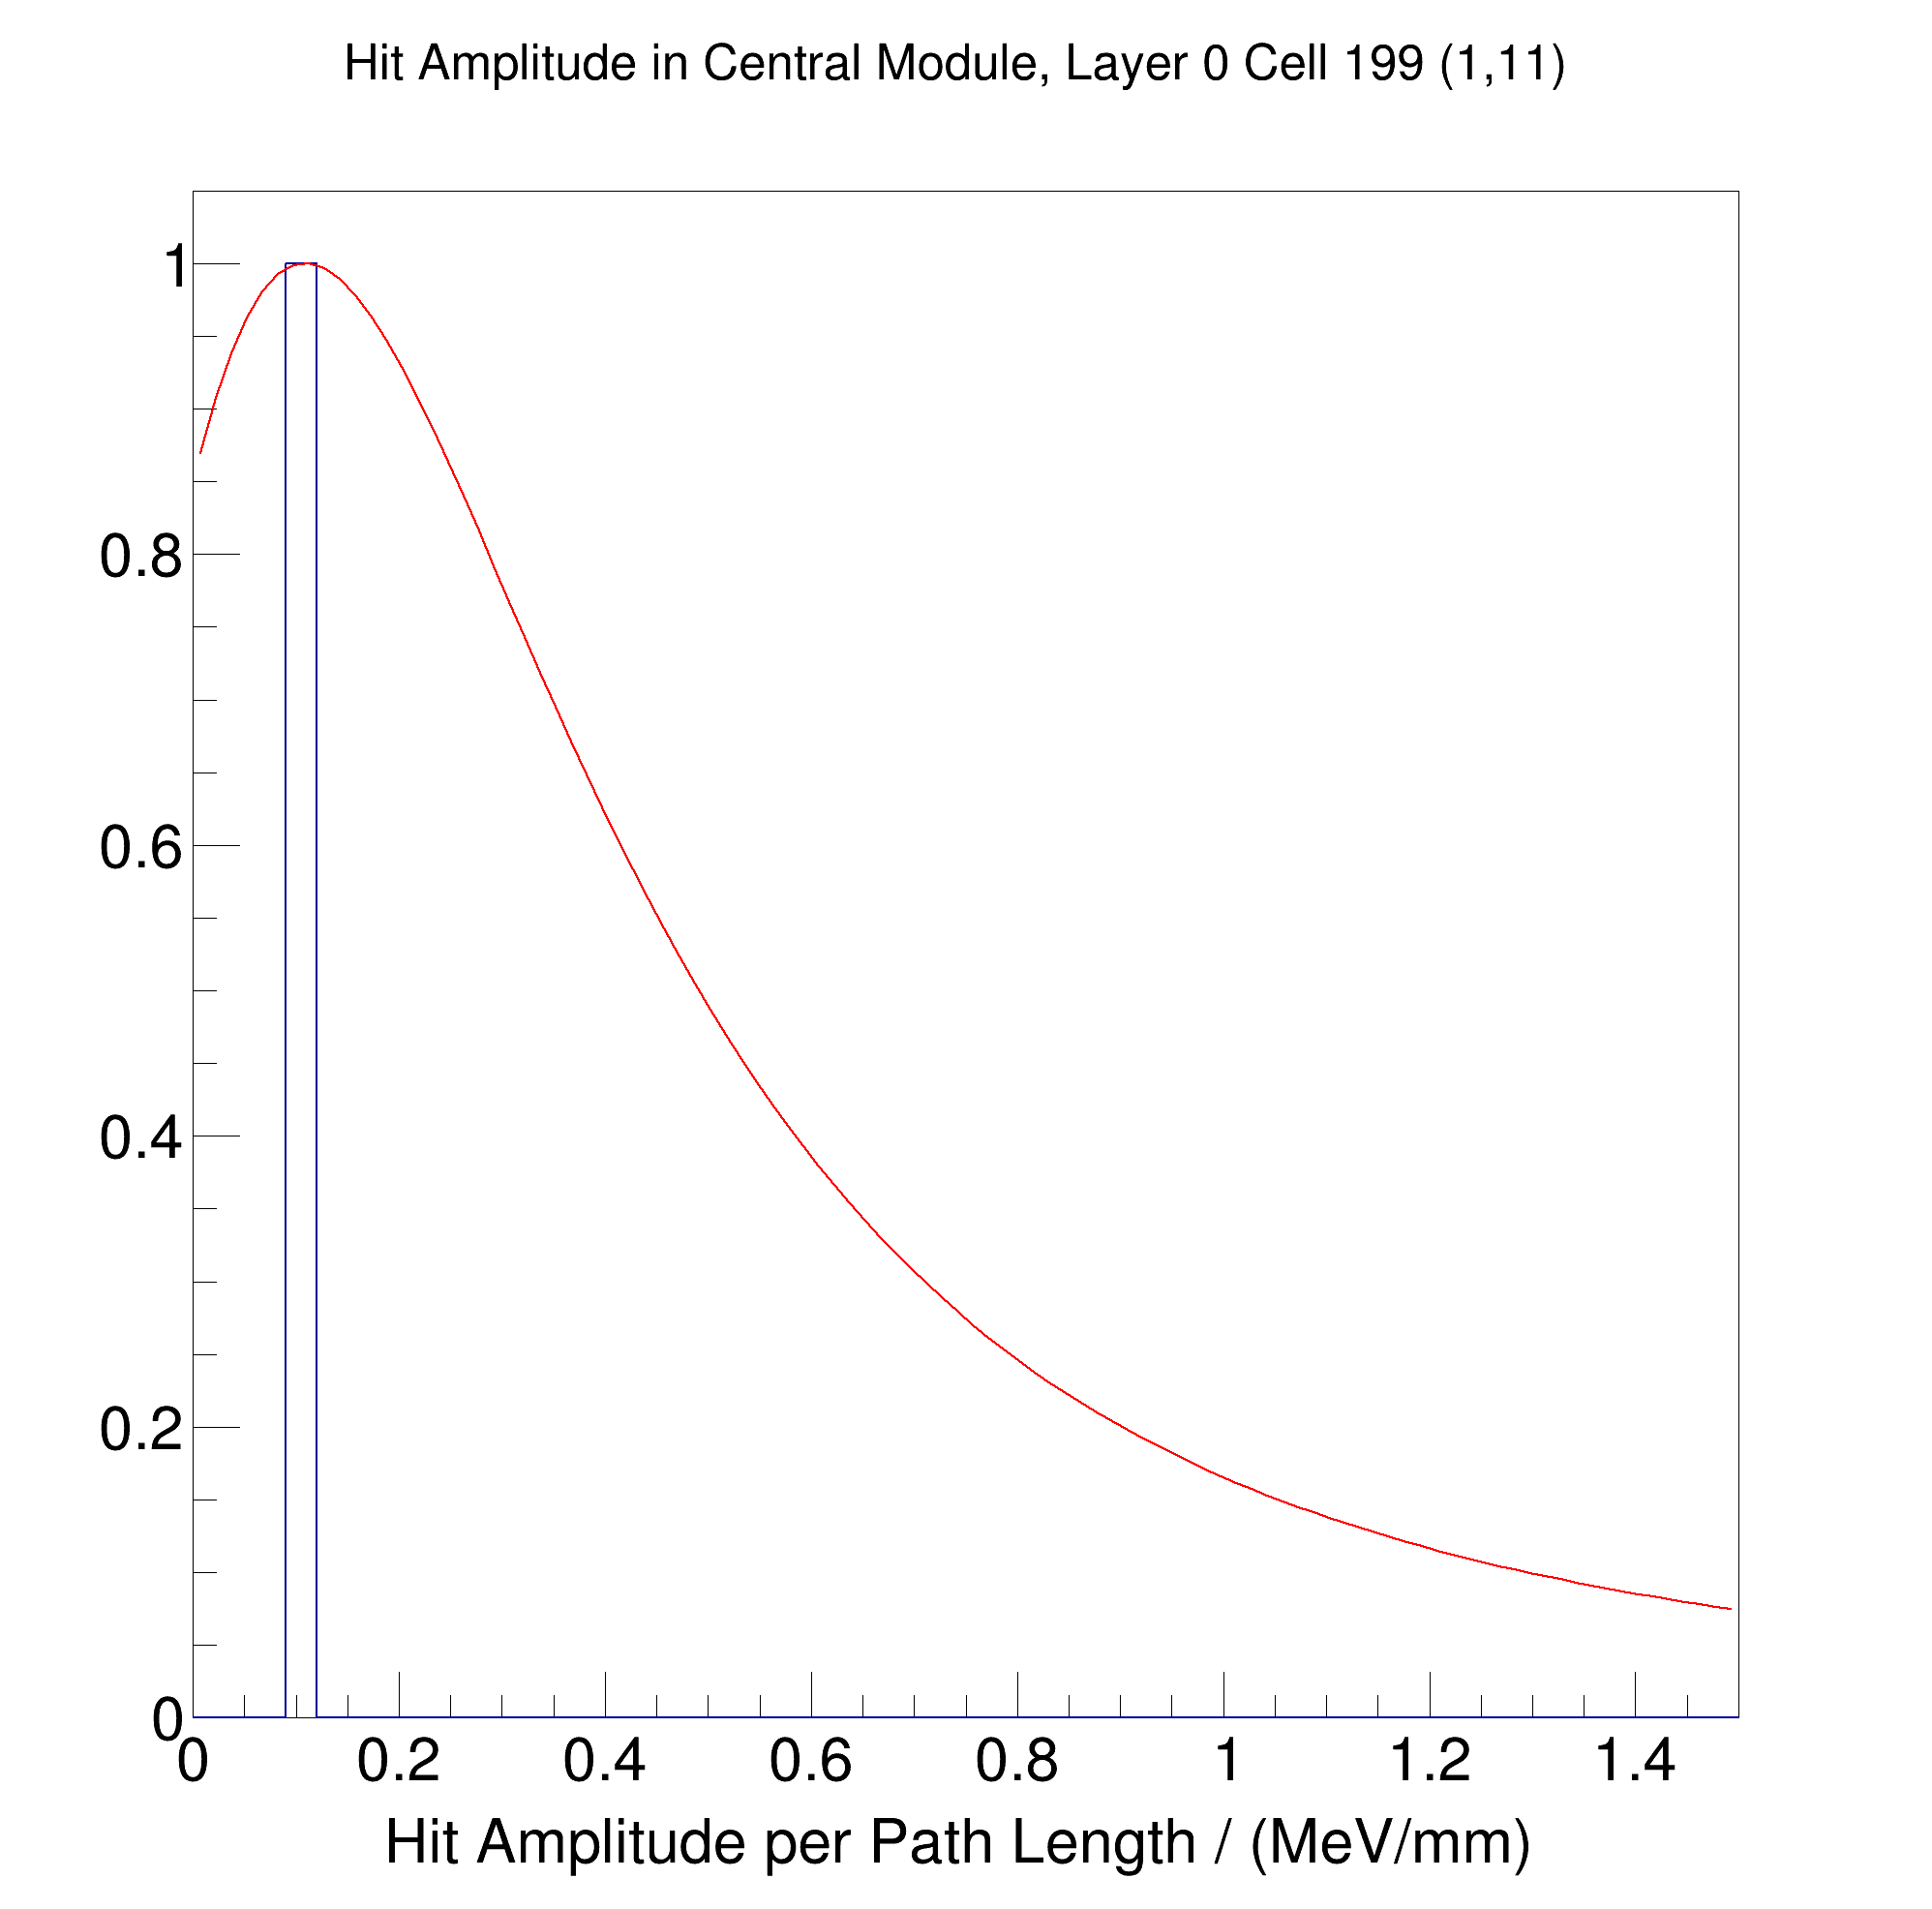

In [55]:
#for x in cell_list:
h = d.Get(b)
h1.GetXaxis().SetRangeUser(0, 1.5)
fr1 = h1.Fit(fl,'BSM').Get()
h1.Draw("SAME")
c.Draw("SAME")

KeyboardInterrupt: 

 FCN=8.32908e-08 FROM HESSE     STATUS=NOT POSDEF     28 CALLS         121 TOTAL
                     EDM=6.61467e-07    STRATEGY= 1      ERR MATRIX NOT POS-DEF
  EXT PARAMETER                APPROXIMATE        STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     5.53583e+00   7.35024e-01   1.08139e-04  -1.04237e-04
   2  MPV          1.42983e-01   4.92420e+00   8.71638e-02   6.06815e-05
   3  Sigma        1.44135e-01   7.02427e+01   3.34752e-03  -1.92178e-05
 FCN=2.39202e-08 FROM HESSE     STATUS=NOT POSDEF     16 CALLS          98 TOTAL
                     EDM=4.82486e-08    STRATEGY= 1      ERR MATRIX NOT POS-DEF
  EXT PARAMETER                APPROXIMATE        STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     5.61126e+00   8.20406e+01   1.09438e-04   5.51339e-05
   2  MPV          2.22626e-01   4.24189e+00   3.05908e-05  -1.98143e-04
   3  Sigma        1.9025

Warning in <Fit>: Fit data is empty 
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <Fit>: Fit data is empty 
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <Fit>: Fit data is empty 
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <Fit>: Fit data is empty 
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <Fit>: Fit data is empty 
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <Fit>: Fit data is empty 
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning 

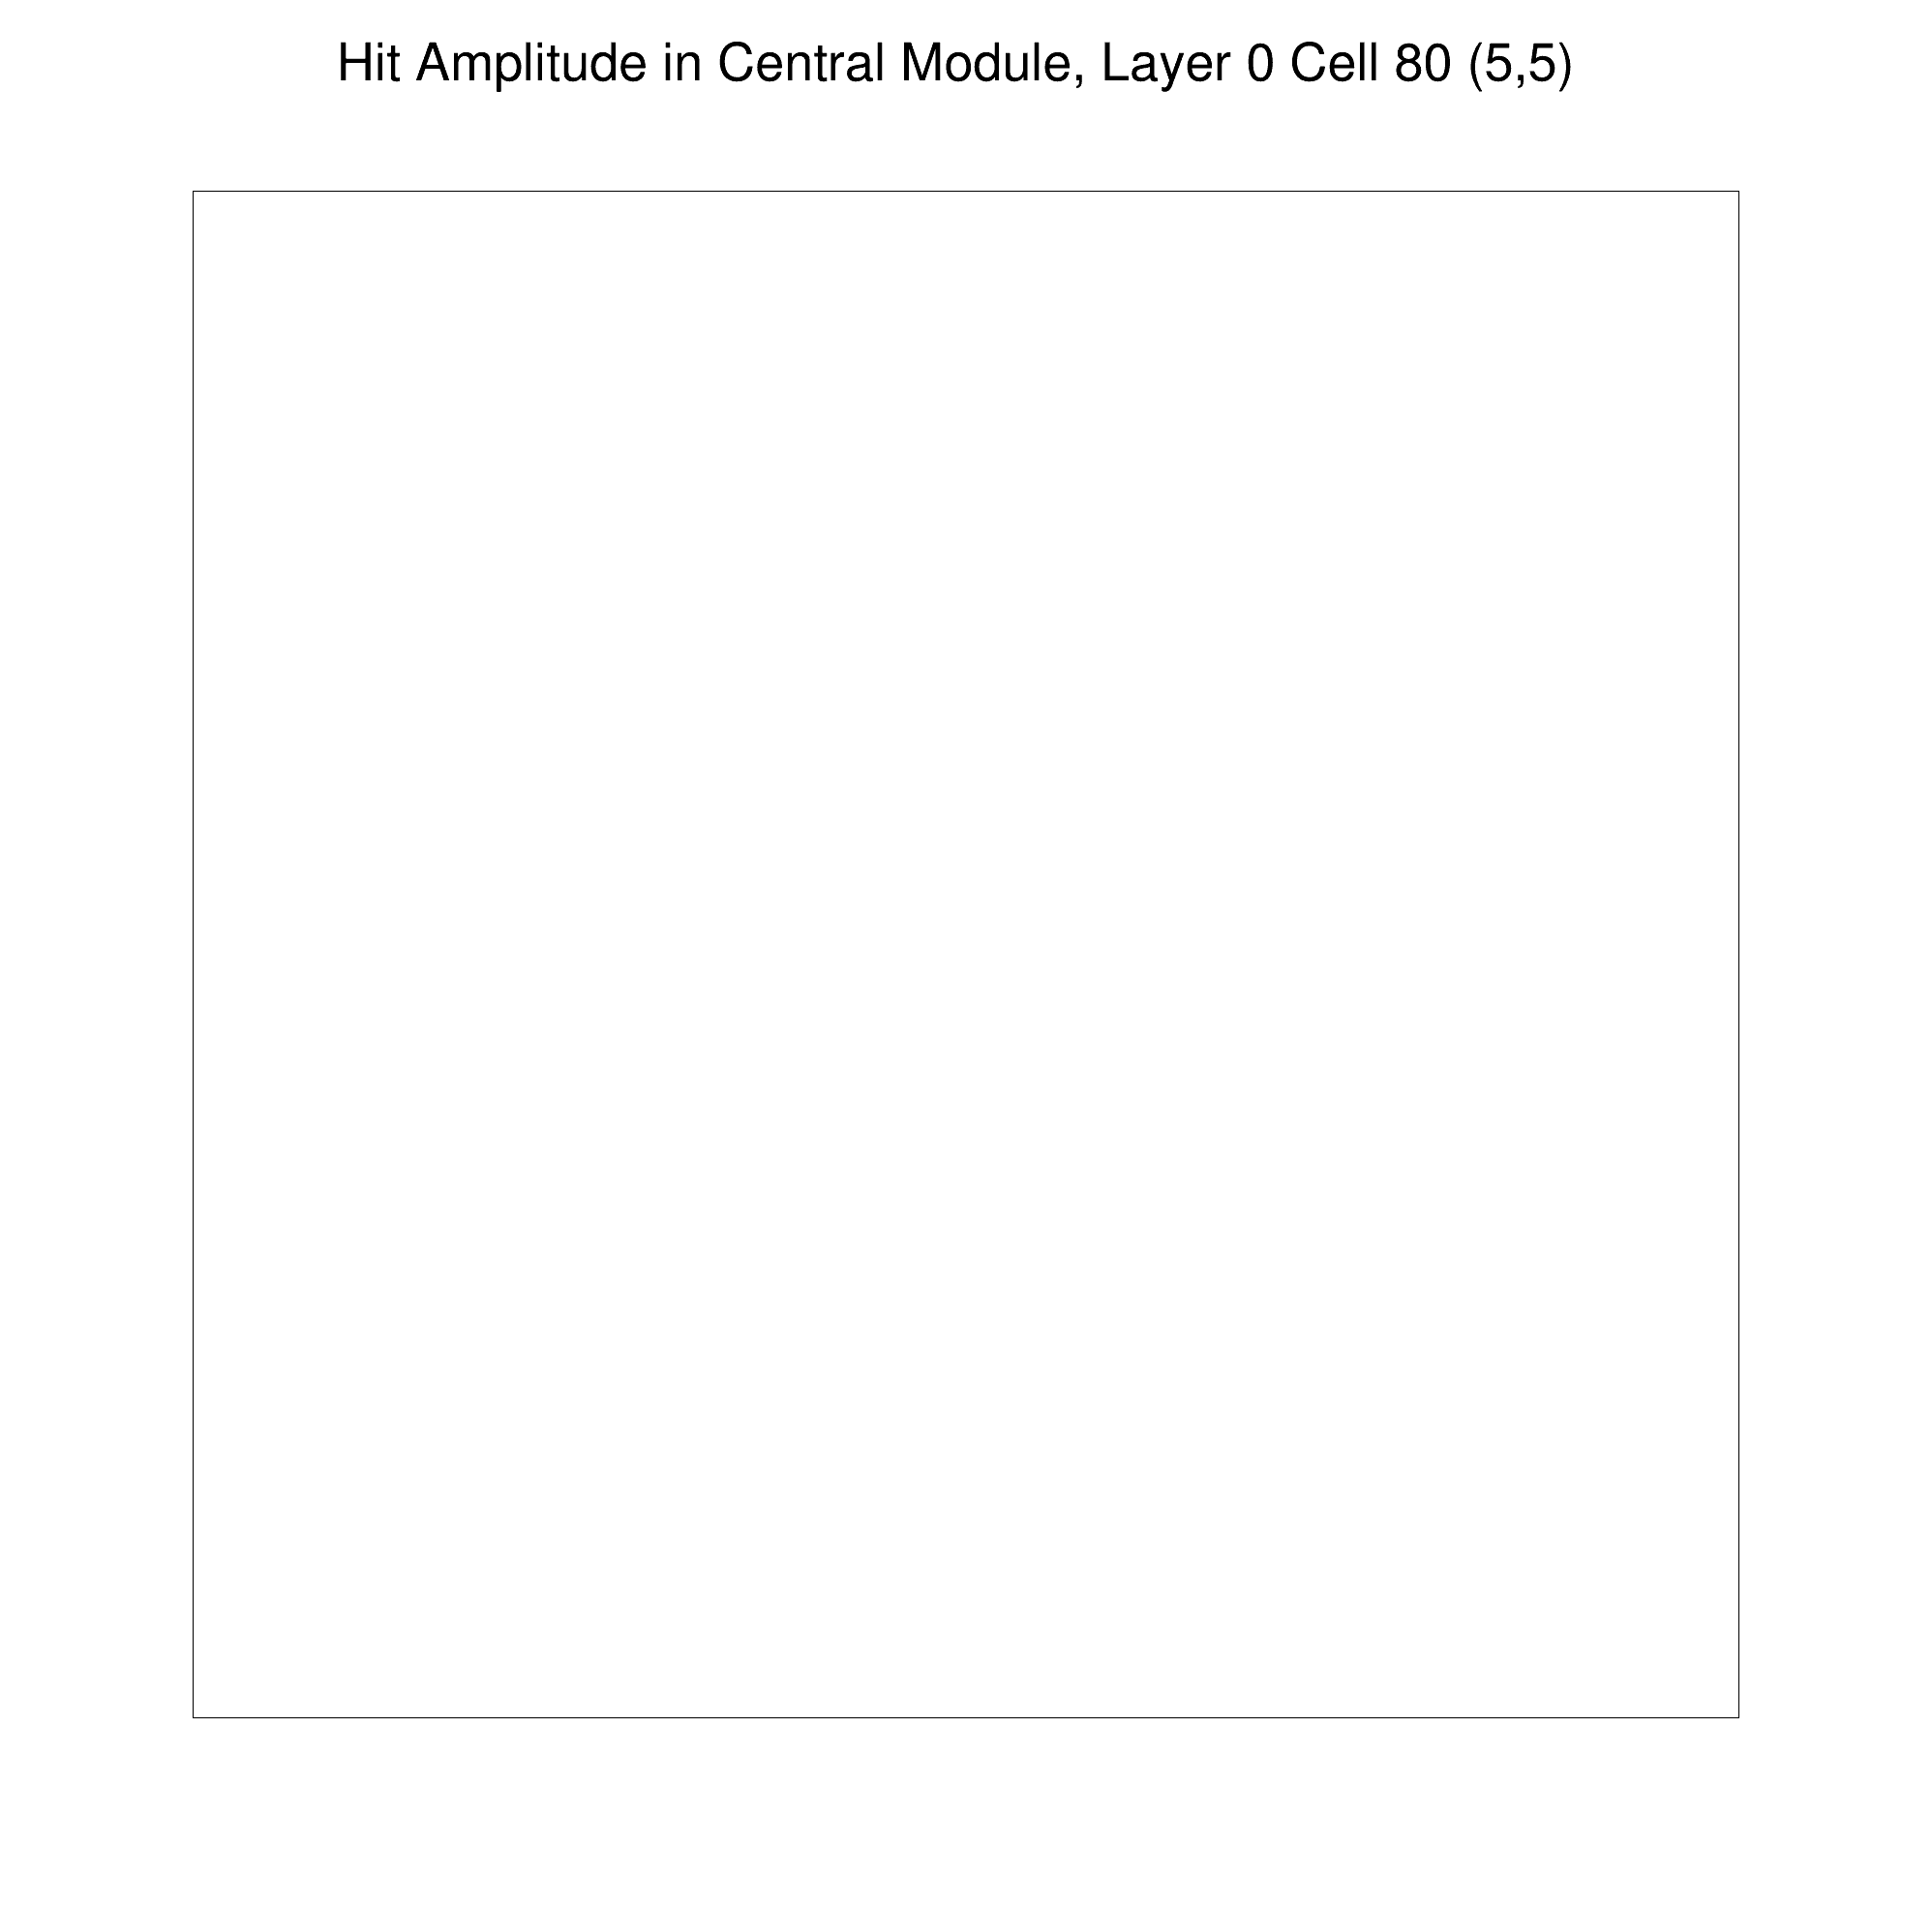

In [10]:

    f = ROOT.TFile('hist-filtering.root')
    d = f.Get('MAC2')
    c = ROOT.TCanvas("c1","c1",2000,2000)
    fl = ROOT.TF1('seedparamslandau','landau')
    fl.SetParameters(1,0.1,0.1)
    fl.SetParLimits(1,0,5)
for x in cell_list:
    h = d.Get(x)
    h.Draw()
    fr = h.Fit(fl,'BSM').Get()
    h.Draw()
    h.GetXaxis().SetRangeUser(0, 1.5)
    c.Draw("Same")

In [ ]:
cell_list

3
4
51
